In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def parse_methanation_data(file_path):
    df = pd.read_json(file_path, orient="index")
    df.columns = df.columns.str.lower()
    df = transform_value_columns(df)    
    df.columns = df.columns.str.replace('moles_', '')
    df = df.drop(columns=['initial_moles'])
    return df

def normalize_units_to_snake_case(units: str) -> str:
    """Convert a unit string like 'mole / second' into snake_case 'mole_per_second'."""
    return re.sub(r'\W+', '_', units.strip().lower()).strip('_')

def transform_value_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transform columns of dicts like {'value': 0.5, 'units': 'mole / second'}
    into float columns, renaming them with unit suffixes.
    """
    new_df = df.copy()
    for col in df.columns:
        # assume column contains dict-like rows
        if isinstance(df[col].iloc[0], dict) and "value" in df[col].iloc[0] and "units" in df[col].iloc[0]:
            values = df[col].apply(lambda x: x["value"])
            units = df[col].iloc[0]["units"]
            unit_snake = normalize_units_to_snake_case(units)
            new_col_name = f"{col}_{unit_snake}"
            new_df[new_col_name] = values
            new_df.drop(columns=[col], inplace=True)
    return new_df

def moles_to_grams(moles, molar_mass):
    return moles * molar_mass

def calculate_grams_and_rates(df):
    df["co2_g"] = moles_to_grams(df["co2_mole"], 44.01)
    df["h2_g"] = moles_to_grams(df["h2_mole"], 2.016)
    df["ch4_g"] = moles_to_grams(df["ch4_mole"], 16.04)
    df["h2o_g"] = moles_to_grams(df["h2o_mole"], 18.015)

    df["co2_consumption_rate_g_per_s"] = df["co2_g"].diff() / df["time_elapsed_second"].diff()
    df["h2_consumption_rate_g_per_s"] = df["h2_g"].diff() / df["time_elapsed_second"].diff()
    df["ch4_production_rate_g_per_s"] = df["ch4_g"].diff() / df["time_elapsed_second"].diff()
    df["h2o_production_rate_g_per_s"] = df["h2o_g"].diff() / df["time_elapsed_second"].diff()
    return df

In [4]:
df_level_1 = parse_methanation_data("methanation_sim_level_1_config_a_results.json")
df_level_1 = calculate_grams_and_rates(df_level_1)

display(df_level_1.head())  
constant_columns = [col for col in df_level_1.columns if df_level_1[col].nunique() == 1]
print("Columns with constant values:", constant_columns)


,time_elapsed_second,rate_constant_mole_second,current_rate_mole_second,actual_rate_mole_second,co2_mole,h2_mole,ch4_mole,h2o_mole,inlet_flow_co2_mole_second,inlet_flow_h2_mole_second,...,total_produced_ch4_mole,total_produced_h2o_mole,co2_g,h2_g,ch4_g,h2o_g,co2_consumption_rate_g_per_s,h2_consumption_rate_g_per_s,ch4_production_rate_g_per_s,h2o_production_rate_g_per_s
0,0.0,0.5,0.5,0.0,10.0,50.0,0.0,0.0,0.0,0.0,...,0.0,0.0,440.100,100.800,0.00,0.000,NaN,NaN,NaN,NaN
5,4.0,0.5,0.5,0.5,8.0,42.0,2.0,4.0,0.0,0.0,...,2.0,4.0,352.080,84.672,32.08,72.060,-22.005,-4.032,8.02,18.015
10,9.0,0.5,0.5,0.5,5.5,32.0,4.5,9.0,0.0,0.0,...,4.5,9.0,242.055,64.512,72.18,162.135,-22.005,-4.032,8.02,18.015
15,14.0,0.5,0.5,0.5,3.0,22.0,7.0,14.0,0.0,0.0,...,7.0,14.0,132.030,44.352,112.28,252.210,-22.005,-4.032,8.02,18.015
20,19.0,0.5,0.5,0.5,0.5,12.0,9.5,19.0,0.0,0.0,...,9.5,19.0,22.005,24.192,152.38,342.285,-22.005,-4.032,8.02,18.015


Columns with constant values: ['rate_constant_mole_second', 'current_rate_mole_second', 'inlet_flow_co2_mole_second', 'inlet_flow_h2_mole_second', 'inlet_flow_ch4_mole_second', 'inlet_flow_h2o_mole_second', 'outlet_flow_co2_mole_second', 'outlet_flow_h2_mole_second', 'outlet_flow_ch4_mole_second', 'outlet_flow_h2o_mole_second']


In [11]:
df_level_1.columns

Index(['time_elapsed_second', 'rate_constant_mole_second',
       'current_rate_mole_second', 'actual_rate_mole_second', 'co2_mole',
       'h2_mole', 'ch4_mole', 'h2o_mole', 'inlet_flow_co2_mole_second',
       'inlet_flow_h2_mole_second', 'inlet_flow_ch4_mole_second',
       'inlet_flow_h2o_mole_second', 'outlet_flow_co2_mole_second',
       'outlet_flow_h2_mole_second', 'outlet_flow_ch4_mole_second',
       'outlet_flow_h2o_mole_second', 'total_consumed_co2_mole',
       'total_consumed_h2_mole', 'total_produced_ch4_mole',
       'total_produced_h2o_mole', 'co2_g', 'h2_g', 'ch4_g', 'h2o_g',
       'co2_consumption_rate_g_per_s', 'h2_consumption_rate_g_per_s',
       'ch4_production_rate_g_per_s', 'h2o_production_rate_g_per_s'],
      dtype='object')

In [17]:
df_level_1[["ch4_g", "h2_g", "co2_g", "h2o_g"]].iloc[0]

ch4_g      0.0
h2_g     100.8
co2_g    440.1
h2o_g      0.0
Name: 0, dtype: float64

In [16]:
df_level_1[["ch4_g", "h2_g", "co2_g", "h2o_g"]].iloc[0].sum(), df_level_1[["ch4_g", "h2_g", "co2_g", "h2o_g"]].iloc[-1].sum()

(np.float64(540.9), np.float64(540.86))

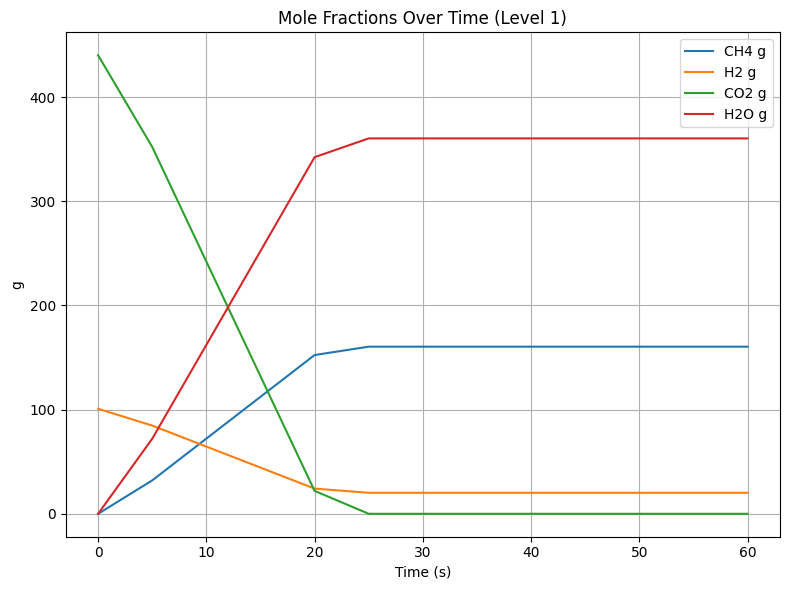

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(df_level_1['ch4_g'], label='CH4 g')
plt.plot(df_level_1['h2_g'], label='H2 g')
plt.plot(df_level_1['co2_g'], label='CO2 g')
plt.plot(df_level_1['h2o_g'], label='H2O g')
plt.title('Mole Fractions Over Time (Level 1)')
plt.xlabel('Time (s)')
plt.ylabel('g')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('../../static/images/methanation_sim_level_1_moles_to_grams.png')


In [11]:
df_level_2 = parse_methanation_data("methanation_sim_level_2_config_a_results.json")
df_level_2 = calculate_grams_and_rates(df_level_2)

display(df_level_2.head())  
constant_columns = [col for col in df_level_2.columns if df_level_2[col].nunique() == 1]
print("Columns with constant values:", constant_columns)

,time_elapsed_second,rate_constant_mole_second,current_rate_mole_second,actual_rate_mole_second,co2_mole,h2_mole,ch4_mole,h2o_mole,total_consumed_co2_mole,total_consumed_h2_mole,...,reactor_volume_meter_3,k_t_meter_12_mole_4_second,co2_g,h2_g,ch4_g,h2o_g,co2_consumption_rate_g_per_s,h2_consumption_rate_g_per_s,ch4_production_rate_g_per_s,h2o_production_rate_g_per_s
0,0.0,0.0,0.0,0.0,10.0,50.0,0.0,0.0,0.0,0.0,...,0.1,0.061746,440.1,100.80,0.0,0.0,NaN,NaN,NaN,NaN
5,5.0,0.0,0.0,0.0,0.0,10.0,10.0,20.0,10.0,40.0,...,0.1,0.061746,0.0,20.16,160.4,360.3,-88.02,-16.128,32.08,72.06
10,10.0,0.0,0.0,0.0,0.0,10.0,10.0,20.0,10.0,40.0,...,0.1,0.061746,0.0,20.16,160.4,360.3,0.00,0.000,0.00,0.00
15,15.0,0.0,0.0,0.0,0.0,10.0,10.0,20.0,10.0,40.0,...,0.1,0.061746,0.0,20.16,160.4,360.3,0.00,0.000,0.00,0.00
20,20.0,0.0,0.0,0.0,0.0,10.0,10.0,20.0,10.0,40.0,...,0.1,0.061746,0.0,20.16,160.4,360.3,0.00,0.000,0.00,0.00


Columns with constant values: ['rate_constant_mole_second', 'current_rate_mole_second', 'actual_rate_mole_second', 'a_pre_exponential_meter_12_mole_4_second', 'ea_joule_mole', 'temperature_kelvin', 'reactor_volume_meter_3', 'k_t_meter_12_mole_4_second']


In [12]:
df_level_3 = parse_methanation_data("methanation_sim_level_3_config_a_results.json")
df_level_3 = calculate_grams_and_rates(df_level_3)

display(df_level_3.head())  
# constant_columns = [col for col in df_level_3.columns if df_level_3[col].nunique() == 1]
# print("Columns with constant values:", constant_columns)

,reactor_type,void_fraction,orders,solver_info,axial_profiles,time_elapsed_second,rate_constant_mole_second,current_rate_meter_12_mole_4_second,actual_rate_mole_second,co2_mole,...,heat_of_reaction_joule_mole,current_reaction_rate_midbed_mole_meter_3_second,co2_g,h2_g,ch4_g,h2o_g,co2_consumption_rate_g_per_s,h2_consumption_rate_g_per_s,ch4_production_rate_g_per_s,h2o_production_rate_g_per_s
0,PFR-Isothermal,0.4,"[1.0, 4.0]",{},NaN,0.0,0.0,0.061746,0.0,10.000000,...,-165000.0,0.000000,440.100000,100.800000,0.000000,0.000000,NaN,NaN,NaN,NaN
5,PFR-Isothermal,0.4,"[1.0, 4.0]","{'success': True, 'status': 0, 'message': 'The...","{'z_fraction': [0.0, 0.006711409395973001, 0.0...",4.0,0.0,0.061746,0.0,8.630852,...,-165000.0,0.127784,379.843797,89.759191,21.961134,49.330402,-15.064051,-2.760202,5.490283,12.3326
10,PFR-Isothermal,0.4,"[1.0, 4.0]","{'success': True, 'status': 0, 'message': 'The...","{'z_fraction': [0.0, 0.006711409395973001, 0.0...",9.0,0.0,0.061746,0.0,6.919417,...,-165000.0,0.127784,304.523544,75.958179,49.412551,110.993404,-15.064051,-2.760202,5.490283,12.3326
15,PFR-Isothermal,0.4,"[1.0, 4.0]","{'success': True, 'status': 0, 'message': 'The...","{'z_fraction': [0.0, 0.006711409395973001, 0.0...",14.0,0.0,0.061746,0.0,5.207982,...,-165000.0,0.127784,229.203290,62.157167,76.863968,172.656407,-15.064051,-2.760202,5.490283,12.3326
20,PFR-Isothermal,0.4,"[1.0, 4.0]","{'success': True, 'status': 0, 'message': 'The...","{'z_fraction': [0.0, 0.006711409395973001, 0.0...",19.0,0.0,0.061746,0.0,3.496547,...,-165000.0,0.127784,153.883037,48.356156,104.315385,234.319409,-15.064051,-2.760202,5.490283,12.3326


In [13]:
df_level_4 = parse_methanation_data("methanation_sim_level_4_config_a_results.json")
df_level_4 = calculate_grams_and_rates(df_level_4)

display(df_level_4.head())  

,reactor_type,void_fraction,porosity,orders,product_orders,equilibrium_constant,solver_info,current_resources,time_elapsed_second,rate_constant_mole_second,...,outlet_temperature_kelvin,outlet_pressure_pascal,co2_g,h2_g,ch4_g,h2o_g,co2_consumption_rate_g_per_s,h2_consumption_rate_g_per_s,ch4_production_rate_g_per_s,h2o_production_rate_g_per_s
0,PFR-Advanced,0.4,0.4,"[1.0, 4.0]","[1.0, 2.0]",7.916208e-17,{},"{'CO2': {'value': 10.0, 'units': 'mole'}, 'H2'...",0.0,0.0,...,673.000000,2.000000e+06,440.100000,100.800000,0.000000,0.000000,NaN,NaN,NaN,NaN
5,PFR-Advanced,0.4,0.4,"[1.0, 4.0]","[1.0, 2.0]",7.916208e-17,"{'success': True, 'status': 0, 'message': 'The...",NaN,4.0,0.0,...,424.461531,1.736338e+06,427.545928,98.499704,4.575490,10.277737,-3.138518,-0.575074,1.143872,2.569434
10,PFR-Advanced,0.4,0.4,"[1.0, 4.0]","[1.0, 2.0]",7.916208e-17,"{'success': True, 'status': 0, 'message': 'The...","{'CO2': {'value': 9.358176283636583, 'units': ...",9.0,0.0,...,424.461531,1.736338e+06,411.853338,95.624334,10.294852,23.124909,-3.138518,-0.575074,1.143872,2.569434
15,PFR-Advanced,0.4,0.4,"[1.0, 4.0]","[1.0, 2.0]",7.916208e-17,"{'success': True, 'status': 0, 'message': 'The...",NaN,14.0,0.0,...,424.461531,1.736338e+06,396.160748,92.748963,16.014215,35.972080,-3.138518,-0.575074,1.143872,2.569434
20,PFR-Advanced,0.4,0.4,"[1.0, 4.0]","[1.0, 2.0]",7.916208e-17,"{'success': True, 'status': 0, 'message': 'The...","{'CO2': {'value': 8.645038821010564, 'units': ...",19.0,0.0,...,424.461531,1.736338e+06,380.468159,89.873593,21.733577,48.819251,-3.138518,-0.575074,1.143872,2.569434


In [46]:
df_level_4_a = df_level_4

df_level_4_b = parse_methanation_data("methanation_sim_level_4_config_b_results.json")
df_level_4_b = calculate_grams_and_rates(df_level_4_b)

df_level_4_c = parse_methanation_data("methanation_sim_level_4_config_c_results.json")
df_level_4_c = calculate_grams_and_rates(df_level_4_c)

In [47]:
df_level_4_a.ch4_g.iloc[-1], df_level_4_b.ch4_g.iloc[-1], df_level_4_c.ch4_g.iloc[-1]

(np.float64(67.48847691307542),
 np.float64(149.96988495842265),
 np.float64(0.05578830179932248))

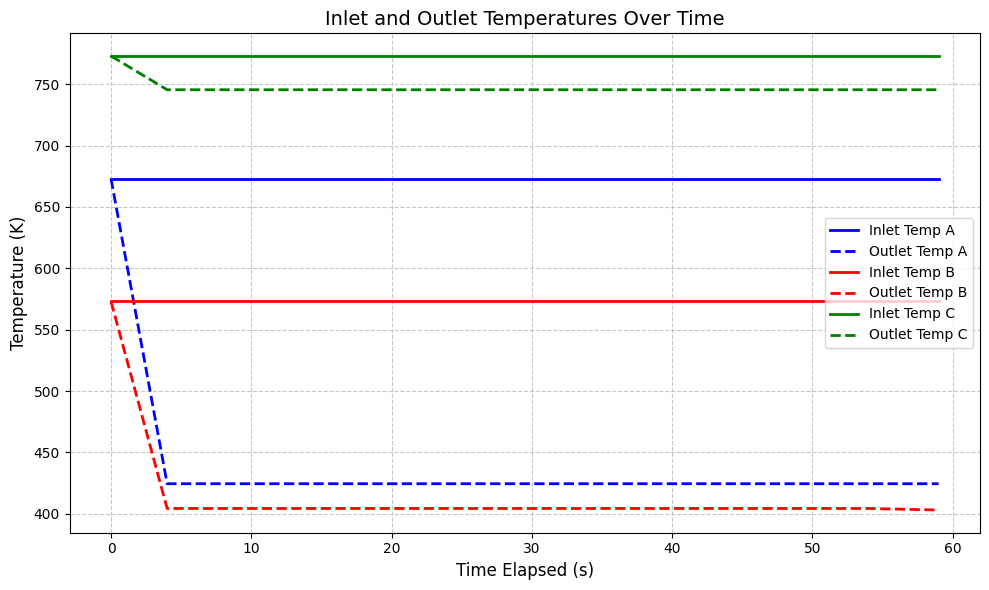

In [48]:
plt.figure(figsize=(10, 6))

# Plot inlet and outlet temperatures for each configuration
plt.plot(df_level_4_a["time_elapsed_second"], df_level_4_a["inlet_temperature_kelvin"], label="Inlet Temp A", color="blue", linewidth=2)
plt.plot(df_level_4_a["time_elapsed_second"], df_level_4_a["outlet_temperature_kelvin"], linestyle="--", label="Outlet Temp A", color="blue", linewidth=2)
plt.plot(df_level_4_b["time_elapsed_second"], df_level_4_b["inlet_temperature_kelvin"], label="Inlet Temp B", color="red", linewidth=2)
plt.plot(df_level_4_b["time_elapsed_second"], df_level_4_b["outlet_temperature_kelvin"], linestyle="--", label="Outlet Temp B", color="red", linewidth=2)
plt.plot(df_level_4_c["time_elapsed_second"], df_level_4_c["inlet_temperature_kelvin"], label="Inlet Temp C", color="green", linewidth=2)
plt.plot(df_level_4_c["time_elapsed_second"], df_level_4_c["outlet_temperature_kelvin"], linestyle="--", label="Outlet Temp C", color="green", linewidth=2)

# Add titles and labels
plt.title("Inlet and Outlet Temperatures Over Time", fontsize=14)
plt.xlabel("Time Elapsed (s)", fontsize=12)
plt.ylabel("Temperature (K)", fontsize=12)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="best", fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()


In [36]:
def calculate_final_mass_and_rate(df):
    final_mass = df["ch4_g"].iloc[-1]
    time_to_final = df.loc[df["ch4_g"] == final_mass, "time_elapsed_second"].iloc[0]
    avg_rate = final_mass / time_to_final if time_to_final > 0 else 0
    return final_mass, time_to_final, avg_rate

final_mass_level_1, time_to_final_level_1, avg_rate_level_1 = calculate_final_mass_and_rate(df_level_1)
print(f"Level 1: Final CH4 mass: {final_mass_level_1:.2f} g, Time to reach final mass: {time_to_final_level_1:.2f} seconds, Average production rate: {avg_rate_level_1:.2f} g/s")
final_mass_level_2, time_to_final_level_2, avg_rate_level_2 = calculate_final_mass_and_rate(df_level_2)
print(f"Level 2: Final CH4 mass: {final_mass_level_2:.2f} g, Time to reach final mass: {time_to_final_level_2:.2f} seconds, Average production rate: {avg_rate_level_2:.2f} g/s")
final_mass_level_3, time_to_final_level_3, avg_rate_level_3 = calculate_final_mass_and_rate(df_level_3)
print(f"Level 3: Final CH4 mass: {final_mass_level_3:.2f} g, Time to reach final mass: {time_to_final_level_3:.2f} seconds, Average production rate: {avg_rate_level_3:.2f} g/s")
final_mass_level_4, time_to_final_level_4, avg_rate_level_4 = calculate_final_mass_and_rate(df_level_4)
print(f"Level 4: Final CH4 mass: {final_mass_level_4:.2f} g, Time to reach final mass: {time_to_final_level_4:.2f} seconds, Average production rate: {avg_rate_level_4:.2f} g/s")


Level 1: Final CH4 mass: 160.40 g, Time to reach final mass: 24.00 seconds, Average production rate: 6.68 g/s
Level 2: Final CH4 mass: 160.40 g, Time to reach final mass: 5.00 seconds, Average production rate: 32.08 g/s
Level 3: Final CH4 mass: 160.40 g, Time to reach final mass: 39.00 seconds, Average production rate: 4.11 g/s
Level 4: Final CH4 mass: 67.49 g, Time to reach final mass: 59.00 seconds, Average production rate: 1.14 g/s


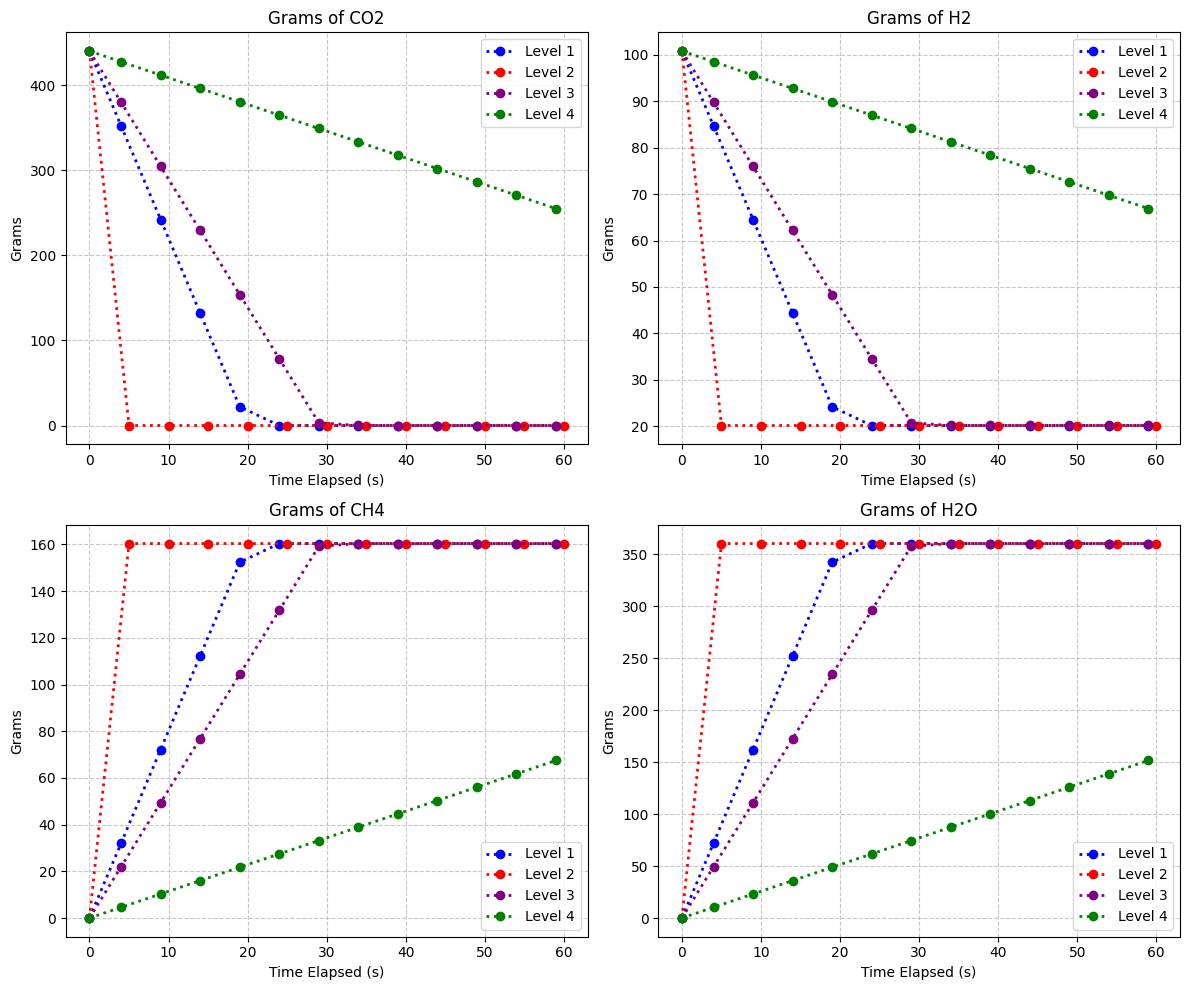

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# CO2
axs[0, 0].plot(df_level_1["time_elapsed_second"], df_level_1["co2_g"], label="Level 1", color="blue", linewidth=2, marker="o", linestyle=":")
axs[0, 0].plot(df_level_2["time_elapsed_second"], df_level_2["co2_g"], label="Level 2", color="red", linewidth=2, marker="o", linestyle=":")
axs[0, 0].plot(df_level_3["time_elapsed_second"], df_level_3["co2_g"], label="Level 3", color="purple", linewidth=2, marker="o", linestyle=":")
axs[0, 0].plot(df_level_4["time_elapsed_second"], df_level_4["co2_g"], label="Level 4", color="green", linewidth=2, marker="o", linestyle=":")
axs[0, 0].set_title("Grams of CO2")
axs[0, 0].set_xlabel("Time Elapsed (s)")
axs[0, 0].set_ylabel("Grams")
axs[0, 0].grid(True, linestyle='--', alpha=0.7)
axs[0, 0].legend()

# H2
axs[0, 1].plot(df_level_1["time_elapsed_second"], df_level_1["h2_g"], label="Level 1", color="blue", linewidth=2, marker="o", linestyle=":")
axs[0, 1].plot(df_level_2["time_elapsed_second"], df_level_2["h2_g"], label="Level 2", color="red", linewidth=2, marker="o", linestyle=":")
axs[0, 1].plot(df_level_3["time_elapsed_second"], df_level_3["h2_g"], label="Level 3", color="purple", linewidth=2, marker="o", linestyle=":")
axs[0, 1].plot(df_level_4["time_elapsed_second"], df_level_4["h2_g"], label="Level 4", color="green", linewidth=2, marker="o", linestyle=":")
axs[0, 1].set_title("Grams of H2")
axs[0, 1].set_xlabel("Time Elapsed (s)")
axs[0, 1].set_ylabel("Grams")
axs[0, 1].grid(True, linestyle='--', alpha=0.7)
axs[0, 1].legend()

# CH4
axs[1, 0].plot(df_level_1["time_elapsed_second"], df_level_1["ch4_g"], label="Level 1", color="blue", linewidth=2, marker="o", linestyle=":")
axs[1, 0].plot(df_level_2["time_elapsed_second"], df_level_2["ch4_g"], label="Level 2", color="red", linewidth=2, marker="o", linestyle=":")
axs[1, 0].plot(df_level_3["time_elapsed_second"], df_level_3["ch4_g"], label="Level 3", color="purple", linewidth=2, marker="o", linestyle=":")
axs[1, 0].plot(df_level_4["time_elapsed_second"], df_level_4["ch4_g"], label="Level 4", color="green", linewidth=2, marker="o", linestyle=":")
axs[1, 0].set_title("Grams of CH4")
axs[1, 0].set_xlabel("Time Elapsed (s)")
axs[1, 0].set_ylabel("Grams")
axs[1, 0].grid(True, linestyle='--', alpha=0.7)
axs[1, 0].legend()

# H2O
axs[1, 1].plot(df_level_1["time_elapsed_second"], df_level_1["h2o_g"], label="Level 1", color="blue", linewidth=2, marker="o", linestyle=":")
axs[1, 1].plot(df_level_2["time_elapsed_second"], df_level_2["h2o_g"], label="Level 2", color="red", linewidth=2, marker="o", linestyle=":")
axs[1, 1].plot(df_level_3["time_elapsed_second"], df_level_3["h2o_g"], label="Level 3", color="purple", linewidth=2, marker="o", linestyle=":")
axs[1, 1].plot(df_level_4["time_elapsed_second"], df_level_4["h2o_g"], label="Level 4", color="green", linewidth=2, marker="o", linestyle=":")
axs[1, 1].set_title("Grams of H2O")
axs[1, 1].set_xlabel("Time Elapsed (s)")
axs[1, 1].set_ylabel("Grams")
axs[1, 1].grid(True, linestyle='--', alpha=0.7)
axs[1, 1].legend()

plt.tight_layout()
plt.show()